
# Data Mining_2_Module_0
## Tabular Data Preparation Pipeline

### Purpose of this notebook

It is the cleaned, operational reconstruction of the final Module 0 tabular workflow.

1. structural inspection and dtype optimization;
2. pre/post-3960 data-quality analysis;
3. discretization harmonization and semantic cleaning;
4. derived-variable construction;
5. removal/reservation of columns before imputation;
6. construction of the 38-column imputation matrix;
7. final sequential single-target Random Forest imputation;
8. reinsertion of reserved variables;
9. post-imputation feature engineering;
10. final semantic/correlation-based column reduction;
11. duplicate removal;
12. saving of the intermediate and final datasets.



## 0. Project paths and output structure


In [1]:

from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

RANDOM_STATE = 42
SPLIT_INDEX = 3960

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

PROJECT_CANDIDATES = [
    Path("/Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/PROGETTO DM2"),
    Path("/Users/sarabiiavasco/Codice/DATA MINING/progetto dm2"),
    Path.cwd(),
    Path.cwd().parent,
]

PROJECT_DIR = next(
    (p for p in PROJECT_CANDIDATES if p.exists()),
    None
)

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Project folder not found. Update PROJECT_CANDIDATES."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "module0_imputation"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def find_project_file(filename: str) -> Path:
    candidates = [
        RAW_DIR / filename,
        PROJECT_DIR / filename,
    ]

    for path in candidates:
        if path.exists():
            return path

    matches = [
        p for p in PROJECT_DIR.rglob(filename)
        if "processed" not in p.parts and "artifacts" not in p.parts
    ]

    if len(matches) == 1:
        return matches[0]

    if len(matches) > 1:
        raise RuntimeError(
            f"Multiple copies of {filename} found:\n"
            + "\n".join(str(p) for p in matches)
        )

    raise FileNotFoundError(
        f"Could not find {filename} inside {PROJECT_DIR}"
    )


DATA_PATH = find_project_file("cmi_internet.csv")
DICTIONARY_PATH = find_project_file("data_dictionary.csv")

print("Project directory:", PROJECT_DIR)
print("Dataset:", DATA_PATH)
print("Data dictionary:", DICTIONARY_PATH)
print("Processed output directory:", PROCESSED_DIR)
print("Imputation artifacts directory:", ARTIFACT_DIR)


Project directory: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2
Dataset: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/cmi_internet.csv
Data dictionary: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data_dictionary.csv
Processed output directory: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed
Imputation artifacts directory: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/artifacts/module0_imputation



## 1. Load the raw tabular dataset


In [2]:

df_raw = pd.read_csv(DATA_PATH)
data_dictionary = pd.read_csv(DICTIONARY_PATH)

print("Raw dataset shape:", df_raw.shape)
print("Data dictionary shape:", data_dictionary.shape)

display(df_raw.head())
display(data_dictionary.head(10))


Raw dataset shape: (8460, 82)
Data dictionary shape: (81, 6)


,id,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-BMI,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,Physical-HeartRate,Physical-Systolic_BP,Fitness_Endurance-Season,Fitness_Endurance-Max_Stage,Fitness_Endurance-Time_Mins,Fitness_Endurance-Time_Sec,FGC-Season,FGC-FGC_CU,FGC-FGC_CU_Zone,FGC-FGC_GSND,FGC-FGC_GSND_Zone,FGC-FGC_GSD,FGC-FGC_GSD_Zone,FGC-FGC_PU,FGC-FGC_PU_Zone,FGC-FGC_SRL,FGC-FGC_SRL_Zone,FGC-FGC_SRR,FGC-FGC_SRR_Zone,FGC-FGC_TL,FGC-FGC_TL_Zone,BIA-Season,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_BMI,BIA-BIA_BMR,BIA-BIA_DEE,BIA-BIA_ECW,BIA-BIA_FFM,BIA-BIA_FFMI,BIA-BIA_FMI,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_ICW,BIA-BIA_LDM,BIA-BIA_LST,BIA-BIA_SMM,BIA-BIA_TBW,PAQ_A-Season,PAQ_A-PAQ_A_Total,PAQ_C-Season,PAQ_C-PAQ_C_Total,PCIAT-Season,PCIAT-PCIAT_01,PCIAT-PCIAT_02,PCIAT-PCIAT_03,PCIAT-PCIAT_04,PCIAT-PCIAT_05,PCIAT-PCIAT_06,PCIAT-PCIAT_07,PCIAT-PCIAT_08,PCIAT-PCIAT_09,PCIAT-PCIAT_10,PCIAT-PCIAT_11,PCIAT-PCIAT_12,PCIAT-PCIAT_13,PCIAT-PCIAT_14,PCIAT-PCIAT_15,PCIAT-PCIAT_16,PCIAT-PCIAT_17,PCIAT-PCIAT_18,PCIAT-PCIAT_19,PCIAT-PCIAT_20,PCIAT-PCIAT_Total,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,sii
0,0,Fall,5,0,Winter,51.0,Fall,16.877316,46.0,50.8,26.0,NaN,NaN,114.0,Spring,5.0,7.0,28.0,Fall,0.0,0.0,NaN,NaN,NaN,NaN,0.0,0.0,7.0,0.0,6.0,0.0,6.0,1.0,Fall,2.0,2.66855,16.8792,932.498,1492.00,8.25598,41.5862,13.8177,3.06143,9.21377,1.0,24.4349,8.89536,38.9177,19.5413,32.6909,Winter,NaN,NaN,NaN,Fall,5.0,4.0,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,4.0,0.0,4.0,4.0,4.0,4.0,4.0,4.0,2.0,4.0,55.0,NaN,NaN,NaN,Fall,3.0,2.0
1,1,Summer,9,0,NaN,NaN,Fall,14.035590,48.0,46.0,22.0,75.0,70.0,122.0,NaN,NaN,NaN,28.0,Fall,3.0,0.0,NaN,2.0,NaN,2.0,5.0,0.0,11.0,1.0,11.0,1.0,3.0,0.0,Winter,2.0,2.57949,14.0371,936.656,1498.65,6.01993,42.0291,12.8254,1.21172,3.97085,1.0,21.0352,14.97400,39.4497,15.4107,27.0552,Winter,2.01,Fall,2.340,Fall,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Fall,46.0,64.0,Summer,0.0,0.0
2,2,Summer,10,1,Fall,71.0,Fall,16.648696,56.5,75.6,NaN,65.0,94.0,117.0,Fall,5.0,7.0,33.0,Fall,20.0,1.0,10.20,1.0,14.7,2.0,7.0,1.0,10.0,1.0,10.0,1.0,5.0,0.0,NaN,NaN,3.92272,17.9665,1115.380,1863.98,15.92800,61.0662,14.0925,3.69863,16.17460,NaN,NaN,NaN,56.9964,NaN,44.9870,NaN,NaN,Summer,2.170,Fall,5.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,2.0,2.0,1.0,1.0,28.0,Fall,38.0,54.0,Summer,2.0,0.0
3,3,Winter,9,0,Fall,71.0,Summer,18.292347,56.0,81.6,26.0,60.0,97.0,117.0,Summer,6.0,9.0,37.0,Summer,18.0,1.0,20.05,NaN,NaN,NaN,5.0,0.0,7.0,0.0,7.0,0.0,7.0,1.0,Summer,3.0,3.84191,18.2943,1131.430,1923.44,15.59250,62.7757,14.0740,4.22033,18.82430,2.0,30.4041,16.77900,58.9338,26.4798,45.9966,NaN,NaN,Winter,2.451,Summer,4.0,2.0,4.0,0.0,5.0,1.0,0.0,3.0,2.0,2.0,3.0,0.0,3.0,0.0,0.0,3.0,4.0,3.0,4.0,1.0,44.0,Summer,31.0,45.0,Winter,0.0,1.0
4,4,Spring,18,1,Summer,65.0,NaN,17.937682,NaN,77.0,26.0,68.0,NaN,NaN,Spring,NaN,NaN,28.0,NaN,9.0,0.0,NaN,2.0,NaN,NaN,3.0,0.0,NaN,1.0,9.0,NaN,10.0,1.0,NaN,NaN,NaN,NaN,NaN,1863.98,15.92800,NaN,NaN,3.69863,16.17460,2.0,28.8558,NaN,56.9964,NaN,NaN,Summer,1.04,Spring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Spring,1.0,0.0


,Instrument,Field,Description,Type,Values,Value Labels
0,Identifier,id,Participant's ID,str,NaN,NaN
1,Demographics,Basic_Demos-Enroll_Season,Season of enrollment,str,"Spring, Summer, Fall, Winter",NaN
2,Demographics,Basic_Demos-Age,Age of participant,float,NaN,NaN
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"
4,Children's Global Assessment Scale,CGAS-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
5,Children's Global Assessment Scale,CGAS-CGAS_Score,Children's Global Assessment Scale Score,int,NaN,NaN
6,Physical Measures,Physical-Season,Season of participation,str,"Spring, Summer, Fall, Winter",NaN
7,Physical Measures,Physical-BMI,Body Mass Index (kg/m^2),float,NaN,NaN
8,Physical Measures,Physical-Height,Height (in),float,NaN,NaN
9,Physical Measures,Physical-Weight,Weight (lbs),float,NaN,NaN



## 2. Structural inspection and dtype optimization

For the transformation pipeline itself, we keep `df_raw` unchanged and use a separate optimized copy, so storage dtypes cannot accidentally alter later calculations.


In [3]:

def optimize_dtypes(data: pd.DataFrame) -> pd.DataFrame:
    df_opt = data.copy()

    for col in df_opt.select_dtypes(include=[np.number]).columns:
        series = df_opt[col]
        observed = series.dropna()

        if len(observed) == 0:
            continue

        if observed.isin([0, 1]).all():
            df_opt[col] = series.astype("boolean")
            continue

        if np.allclose(observed, np.rint(observed)):
            min_val = observed.min()
            max_val = observed.max()

            if min_val >= 0:
                if max_val <= np.iinfo(np.uint8).max:
                    dtype = "UInt8"
                elif max_val <= np.iinfo(np.uint16).max:
                    dtype = "UInt16"
                elif max_val <= np.iinfo(np.uint32).max:
                    dtype = "UInt32"
                else:
                    dtype = "UInt64"
            else:
                if np.iinfo(np.int8).min <= min_val and max_val <= np.iinfo(np.int8).max:
                    dtype = "Int8"
                elif np.iinfo(np.int16).min <= min_val and max_val <= np.iinfo(np.int16).max:
                    dtype = "Int16"
                elif np.iinfo(np.int32).min <= min_val and max_val <= np.iinfo(np.int32).max:
                    dtype = "Int32"
                else:
                    dtype = "Int64"

            df_opt[col] = series.astype(dtype)
        else:
            df_opt[col] = series.astype("Float32")

    for col in df_opt.select_dtypes(include=["object"]).columns:
        series = df_opt[col].astype("string")
        missing_mask = series.isna()

        series = (
            series
            .str.lower()
            .str.strip()
            .str.replace(r"\s+", " ", regex=True)
        )
        series[missing_mask] = pd.NA

        if series.nunique(dropna=True) <= 100:
            df_opt[col] = series.astype("category")
        else:
            df_opt[col] = series

    return df_opt


memory_before = df_raw.memory_usage(deep=True).sum() / 1024**2
df_optimized = optimize_dtypes(df_raw)
memory_after = df_optimized.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before: {memory_before:.2f} MB")
print(f"Memory after:  {memory_after:.2f} MB")
print(
    "Reduction:",
    f"{(memory_before - memory_after) / memory_before * 100:.2f}%"
)


Memory before: 8.96 MB
Memory after:  2.09 MB
Reduction: 76.64%



## 3. Preliminary data-quality assessment

We identified a clear discontinuity around row 3960. We later investigated this phenomenon.


In [4]:

quality_summary = pd.DataFrame({
    "metric": [
        "rows",
        "columns",
        "duplicate IDs",
        "complete duplicate rows in raw data",
        "rows with at least one missing value",
        "missing cells",
        "mean missing values per row",
    ],
    "value": [
        len(df_raw),
        df_raw.shape[1],
        int(df_raw["id"].duplicated().sum()),
        int(df_raw.duplicated().sum()),
        int(df_raw.isna().any(axis=1).sum()),
        int(df_raw.isna().sum().sum()),
        float(df_raw.isna().sum(axis=1).mean()),
    ],
})

display(quality_summary)


,metric,value
0,rows,8460.00000
1,columns,82.00000
2,duplicate IDs,0.00000
3,complete duplicate rows in raw data,0.00000
4,rows with at least one missing value,8428.00000
5,missing cells,229177.00000
6,mean missing values per row,27.08948


In [5]:

pre = df_raw.iloc[:SPLIT_INDEX]
post = df_raw.iloc[SPLIT_INDEX:]

missingness_summary = pd.DataFrame([
    {
        "subset": "full",
        "n_rows": len(df_raw),
        "% rows with missing": df_raw.isna().any(axis=1).mean() * 100,
        "% missing cells": df_raw.isna().mean().mean() * 100,
        "mean missing / row": df_raw.isna().sum(axis=1).mean(),
    },
    {
        "subset": "pre-3960",
        "n_rows": len(pre),
        "% rows with missing": pre.isna().any(axis=1).mean() * 100,
        "% missing cells": pre.isna().mean().mean() * 100,
        "mean missing / row": pre.isna().sum(axis=1).mean(),
    },
    {
        "subset": "post-3960",
        "n_rows": len(post),
        "% rows with missing": post.isna().any(axis=1).mean() * 100,
        "% missing cells": post.isna().mean().mean() * 100,
        "mean missing / row": post.isna().sum(axis=1).mean(),
    },
])

display(missingness_summary.round(3))

missing_pre_post = pd.DataFrame({
    "pre_3960_%": pre.isna().mean() * 100,
    "post_3960_%": post.isna().mean() * 100,
})
missing_pre_post["delta_pp"] = (
    missing_pre_post["post_3960_%"]
    - missing_pre_post["pre_3960_%"]
)

display(
    missing_pre_post
    .sort_values("delta_pp", ascending=False)
    .head(20)
    .round(2)
)


,subset,n_rows,% rows with missing,% missing cells,mean missing / row
0,full,8460,99.622,33.036,27.089
1,pre-3960,3960,99.192,24.930,20.442
2,post-3960,4500,100.000,40.169,32.939


,pre_3960_%,post_3960_%,delta_pp
PCIAT-PCIAT_13,31.82,99.69,67.87
PCIAT-PCIAT_12,31.82,99.69,67.87
PCIAT-PCIAT_01,31.82,99.69,67.87
PCIAT-PCIAT_02,31.82,99.69,67.87
PCIAT-PCIAT_03,31.82,99.69,67.87
PCIAT-PCIAT_04,31.82,99.69,67.87
PCIAT-PCIAT_05,31.82,99.69,67.87
PCIAT-PCIAT_06,31.82,99.69,67.87
PCIAT-PCIAT_07,31.82,99.69,67.87
PCIAT-PCIAT_08,31.82,99.69,67.87


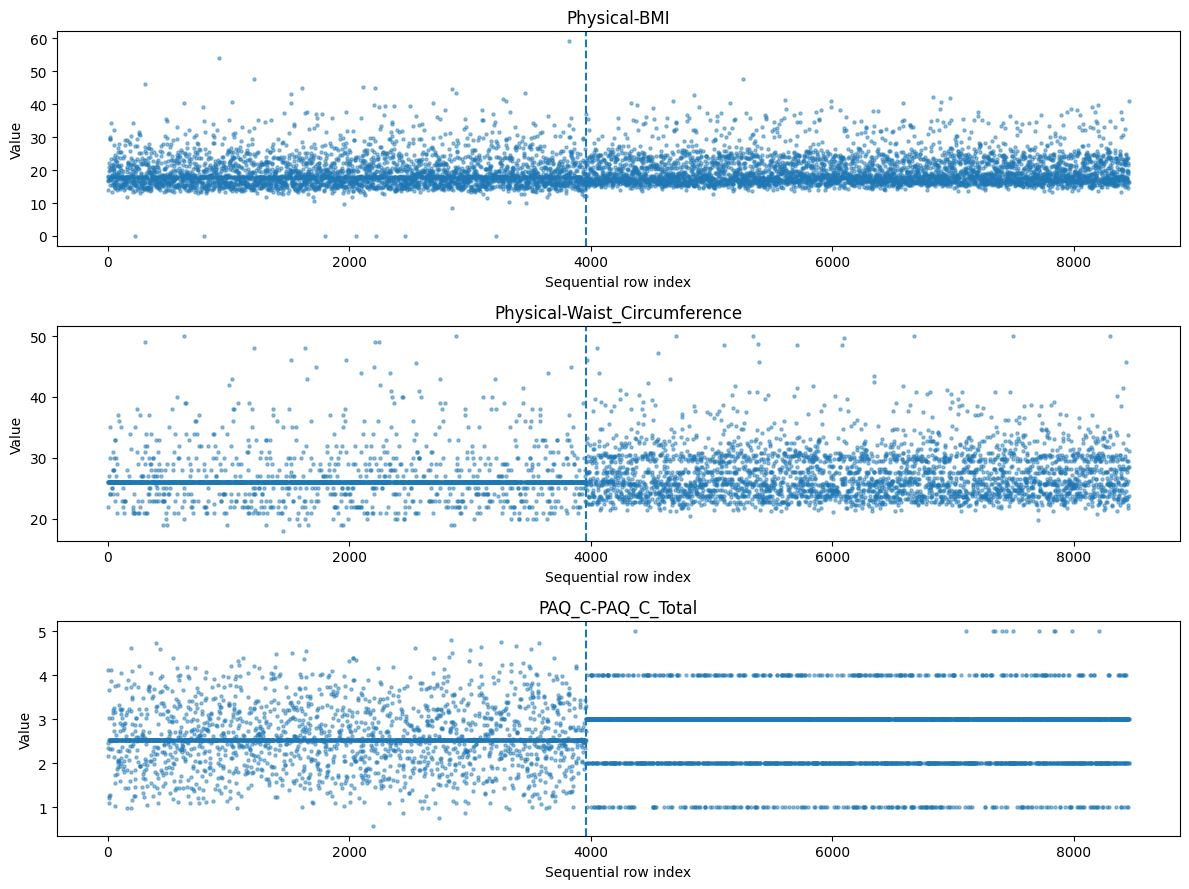

In [6]:

representative_columns = [
    "Physical-BMI",
    "Physical-Waist_Circumference",
    "PAQ_C-PAQ_C_Total",
]

fig, axes = plt.subplots(
    len(representative_columns),
    1,
    figsize=(12, 9)
)

for ax, col in zip(axes, representative_columns):
    ax.scatter(
        df_raw.index,
        df_raw[col],
        s=5,
        alpha=0.45
    )
    ax.axvline(SPLIT_INDEX, linestyle="--")
    ax.set_title(col)
    ax.set_xlabel("Sequential row index")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()



## 4. Discretization harmonization and semantic cleaning

A modification log is built while cleaning so that every value converted to missing can be audited afterwards.


In [7]:

df_semantic = df_raw.copy(deep=True)

change_log = []


def set_invalid_to_nan(data, column, invalid_mask, reason):
    invalid_mask = invalid_mask.fillna(False)
    n_changed = int(invalid_mask.sum())

    if n_changed:
        sample_indices = data.index[invalid_mask][:10].tolist()
        change_log.append({
            "column": column,
            "reason": reason,
            "n_changed": n_changed,
            "sample_indices": sample_indices,
        })
        data.loc[invalid_mask, column] = np.nan

    return n_changed


def round_quarter(series):
    return np.round(pd.to_numeric(series, errors="coerce") * 4) / 4


def round_positive_nearest_integer(series):
    values = pd.to_numeric(series, errors="coerce")
    return np.floor(values + 0.499999)


### 4.1 CGAS

In [8]:

df_semantic["CGAS-CGAS_Score"] = np.floor(
    pd.to_numeric(df_semantic["CGAS-CGAS_Score"], errors="coerce")
)

set_invalid_to_nan(
    df_semantic,
    "CGAS-CGAS_Score",
    (
        df_semantic["CGAS-CGAS_Score"].notna()
        & ~df_semantic["CGAS-CGAS_Score"].between(1, 100)
    ),
    "CGAS score outside [1, 100]",
)


16


### 4.2 Physical measurements

The final working code:

- quantizes height and weight to 0.25;
- removes zero / very low weights;
- harmonizes waist circumference;
- floors blood pressure and heart rate;
- applies the broad semantic ranges used in the source notebook;
- recalculates BMI using the imperial formula.


In [9]:

df_semantic["Physical-Height"] = round_quarter(
    df_semantic["Physical-Height"]
)

df_semantic["Physical-Weight"] = round_quarter(
    df_semantic["Physical-Weight"]
)

set_invalid_to_nan(
    df_semantic,
    "Physical-Weight",
    (
        df_semantic["Physical-Weight"].notna()
        & (df_semantic["Physical-Weight"] < 30)
    ),
    "Physical weight below 30 lb",
)

df_semantic["Physical-Waist_Circumference"] = np.floor(
    pd.to_numeric(
        df_semantic["Physical-Waist_Circumference"],
        errors="coerce",
    )
    + 0.5
)

for col in [
    "Physical-Diastolic_BP",
    "Physical-HeartRate",
    "Physical-Systolic_BP",
]:
    df_semantic[col] = np.floor(
        pd.to_numeric(df_semantic[col], errors="coerce")
    )

physical_ranges = {
    "Physical-Diastolic_BP": (40, 110),
    "Physical-HeartRate": (40, 180),
    "Physical-Systolic_BP": (70, 160),
}

for col, (lower, upper) in physical_ranges.items():
    set_invalid_to_nan(
        df_semantic,
        col,
        (
            df_semantic[col].notna()
            & ~df_semantic[col].between(lower, upper)
        ),
        f"{col} outside [{lower}, {upper}]",
    )

df_semantic["Physical-BMI_recalc"] = np.where(
    (
        df_semantic["Physical-Height"].isna()
        | df_semantic["Physical-Weight"].isna()
    ),
    np.nan,
    (
        703
        * df_semantic["Physical-Weight"]
        / np.square(df_semantic["Physical-Height"])
    ),
)

print(
    "Physical-BMI vs recalculated BMI correlation:",
    round(
        df_semantic[
            ["Physical-BMI", "Physical-BMI_recalc"]
        ]
        .corr()
        .iloc[0, 1],
        4,
    ),
)


Physical-BMI vs recalculated BMI correlation: 0.5892


### 4.3 Endurance variables

In [10]:

for col in [
    "Fitness_Endurance-Max_Stage",
    "Fitness_Endurance-Time_Mins",
    "Fitness_Endurance-Time_Sec",
]:
    df_semantic[col] = np.floor(
        pd.to_numeric(df_semantic[col], errors="coerce")
    )

set_invalid_to_nan(
    df_semantic,
    "Fitness_Endurance-Time_Sec",
    (
        df_semantic["Fitness_Endurance-Time_Sec"].notna()
        & ~df_semantic["Fitness_Endurance-Time_Sec"].between(0, 59)
    ),
    "Endurance seconds outside [0, 59]",
)


0

### 4.4 FitnessGram variables

In [11]:

df_semantic["FGC-FGC_CU"] = np.floor(
    pd.to_numeric(df_semantic["FGC-FGC_CU"], errors="coerce")
)

for col in ["FGC-FGC_GSND", "FGC-FGC_GSD"]:
    df_semantic[col] = round_quarter(df_semantic[col])

for col in ["FGC-FGC_SRL", "FGC-FGC_SRR", "FGC-FGC_TL"]:
    df_semantic[col] = round_positive_nearest_integer(
        df_semantic[col]
    )

for col in [
    "FGC-FGC_CU",
    "FGC-FGC_GSND",
    "FGC-FGC_GSD",
    "FGC-FGC_PU",
    "FGC-FGC_SRL",
    "FGC-FGC_SRR",
    "FGC-FGC_TL",
]:
    set_invalid_to_nan(
        df_semantic,
        col,
        (
            pd.to_numeric(df_semantic[col], errors="coerce").notna()
            & (pd.to_numeric(df_semantic[col], errors="coerce") < 0)
        ),
        f"{col} negative",
    )



### 4.5 BIA variables

We removed negative BIA values and values above broad hard maxima.  
These limits were intentionally broad: statistical extremes that remained semantically possible were kept for Module 1 outlier detection.


In [12]:

bia_hard_max = {
    "BIA-BIA_BMC": 20,
    "BIA-BIA_BMI": 120,
    "BIA-BIA_BMR": 10000,
    "BIA-BIA_DEE": 20000,
    "BIA-BIA_ECW": 100,
    "BIA-BIA_FFM": 250,
    "BIA-BIA_FFMI": 60,
    "BIA-BIA_FMI": 80,
    "BIA-BIA_Fat": 100,
    "BIA-BIA_ICW": 100,
    "BIA-BIA_LDM": 80,
    "BIA-BIA_LST": 250,
    "BIA-BIA_SMM": 150,
    "BIA-BIA_TBW": 150,
}

for col, upper in bia_hard_max.items():
    df_semantic[col] = pd.to_numeric(
        df_semantic[col],
        errors="coerce",
    )

    set_invalid_to_nan(
        df_semantic,
        col,
        (
            df_semantic[col].notna()
            & (
                (df_semantic[col] < 0)
                | (df_semantic[col] > upper)
            )
        ),
        f"{col} outside [0, {upper}]",
    )



### 4.6 PAQ-A and PAQ-C

We used **14 years** as the threshold:

- age < 14 → retain PAQ-C;
- age ≥ 14 → retain PAQ-A.

The two variables are not merged yet. They are merged immediately before the imputation matrix is built.


In [13]:

for col in [
    "PAQ_A-PAQ_A_Total",
    "PAQ_C-PAQ_C_Total",
]:
    values = pd.to_numeric(
        df_semantic[col],
        errors="coerce",
    )

    values = np.floor(values + 0.5)

    df_semantic[col] = pd.Series(
        values,
        index=df_semantic.index,
    ).where(
        pd.Series(values, index=df_semantic.index)
        .between(1, 5)
    )

age_col = "Basic_Demos-Age"

age_inconsistent_a = (
    df_semantic["PAQ_A-PAQ_A_Total"].notna()
    & (df_semantic[age_col] < 14)
)
age_inconsistent_c = (
    df_semantic["PAQ_C-PAQ_C_Total"].notna()
    & (df_semantic[age_col] >= 14)
)

set_invalid_to_nan(
    df_semantic,
    "PAQ_A-PAQ_A_Total",
    age_inconsistent_a,
    "PAQ-A observed for age < 14",
)

set_invalid_to_nan(
    df_semantic,
    "PAQ_C-PAQ_C_Total",
    age_inconsistent_c,
    "PAQ-C observed for age >= 14",
)

both_paq = (
    df_semantic["PAQ_A-PAQ_A_Total"].notna()
    & df_semantic["PAQ_C-PAQ_C_Total"].notna()
)

print("Rows with both PAQ versions still observed:", int(both_paq.sum()))


Rows with both PAQ versions still observed: 0


### 4.7 SDS

In [14]:

for col in ["SDS-SDS_Total_Raw", "SDS-SDS_Total_T"]:
    df_semantic[col] = np.floor(
        pd.to_numeric(df_semantic[col], errors="coerce")
    )



### 4.8 Semantic-cleaning audit

The five rows with `Systolic <= Diastolic` were converted to missing **before** imputation.


In [15]:

change_log_df = pd.DataFrame(change_log)

print("Semantic-cleaning actions:")
display(
    change_log_df.sort_values(
        ["column", "reason"]
    ).reset_index(drop=True)
)

print(
    "Total cells converted to NaN by the explicit semantic rules above:",
    int(change_log_df["n_changed"].sum())
)

bp_inconsistent_pre = (
    df_semantic["Physical-Systolic_BP"].notna()
    & df_semantic["Physical-Diastolic_BP"].notna()
    & (
        df_semantic["Physical-Systolic_BP"]
        <= df_semantic["Physical-Diastolic_BP"]
    )
)

print(
    "Observed rows with Systolic <= Diastolic before imputation:",
    int(bp_inconsistent_pre.sum())
)

display(
    df_semantic.loc[
        bp_inconsistent_pre,
        [
            "id",
            "Basic_Demos-Age",
            "Physical-Systolic_BP",
            "Physical-Diastolic_BP",
            "Physical-HeartRate",
        ],
    ]
)


Semantic-cleaning actions:


,column,reason,n_changed,sample_indices
0,BIA-BIA_BMC,"BIA-BIA_BMC outside [0, 20]",79,"[55, 72, 113, 180, 232, 238, 609, 635, 646, 655]"
1,BIA-BIA_BMR,"BIA-BIA_BMR outside [0, 10000]",7,"[3205, 3511, 4626, 5520, 6869, 6956, 8391]"
2,BIA-BIA_DEE,"BIA-BIA_DEE outside [0, 20000]",8,"[3205, 4837, 5221, 5448, 5615, 6010, 6273, 6763]"
3,BIA-BIA_ECW,"BIA-BIA_ECW outside [0, 100]",27,"[2299, 2490, 3205, 3511, 3774, 3968, 5028, 520..."
4,BIA-BIA_FFM,"BIA-BIA_FFM outside [0, 250]",35,"[2299, 2490, 2770, 3147, 3205, 3511, 3630, 372..."
5,BIA-BIA_FFMI,"BIA-BIA_FFMI outside [0, 60]",20,"[2770, 3147, 3511, 3729, 4074, 4360, 4996, 510..."
6,BIA-BIA_FMI,"BIA-BIA_FMI outside [0, 80]",51,"[156, 498, 840, 1030, 1170, 1287, 1656, 1658, ..."
7,BIA-BIA_Fat,"BIA-BIA_Fat outside [0, 100]",169,"[156, 306, 482, 498, 785, 840, 872, 921, 1030,..."
8,BIA-BIA_ICW,"BIA-BIA_ICW outside [0, 100]",30,"[2299, 2490, 2770, 3147, 3205, 3511, 3630, 372..."
9,BIA-BIA_LDM,"BIA-BIA_LDM outside [0, 80]",31,"[2299, 2490, 3205, 3511, 3774, 4028, 4197, 425..."


Total cells converted to NaN by the explicit semantic rules above: 6013
Observed rows with Systolic <= Diastolic before imputation: 5


,id,Basic_Demos-Age,Physical-Systolic_BP,Physical-Diastolic_BP,Physical-HeartRate
2386,2386,8,76.0,76.0,116.0
3344,3344,18,73.0,98.0,96.0
4694,4694,5,103.0,108.0,83.0
5440,5440,6,100.0,101.0,105.0
7187,7187,5,104.0,108.0,109.0



## 5. Save the post-cleaning / pre-imputation dataset

This is the cleaned dataset that replaces the many temporary versions used during development.


In [16]:

PRE_IMPUTATION_PATH = (
    PROCESSED_DIR
    / "01_cmi_internet_discretizzato_pre_imputation.csv"
)

df_semantic.to_csv(
    PRE_IMPUTATION_PATH,
    index=False,
)

print("Saved:", PRE_IMPUTATION_PATH)
print("Shape:", df_semantic.shape)


Saved: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed/01_cmi_internet_discretizzato_pre_imputation.csv
Shape: (8460, 83)



## 6. Correlation analysis before reduction

The correlation matrix is used as a redundancy diagnostic.  
In particular, `PCIAT-PCIAT_Total` is strongly related to `sii`, so neither is used in the feature-imputation matrix.


In [17]:

corr = df_semantic.corr(numeric_only=True)

print(
    "Correlation PCIAT-PCIAT_Total vs sii:",
    round(
        corr.loc[
            "PCIAT-PCIAT_Total",
            "sii",
        ],
        4,
    ),
)

CORR_THRESHOLD = 0.80

strong_pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        value = corr.iloc[i, j]

        if pd.notna(value) and abs(value) > CORR_THRESHOLD:
            strong_pairs.append({
                "variable_1": corr.columns[i],
                "variable_2": corr.columns[j],
                "pearson_r": value,
            })

strong_pairs_df = (
    pd.DataFrame(strong_pairs)
    .assign(abs_r=lambda x: x["pearson_r"].abs())
    .sort_values("abs_r", ascending=False)
    .drop(columns="abs_r")
    .reset_index(drop=True)
)

display(strong_pairs_df)


Correlation PCIAT-PCIAT_Total vs sii: 0.8986


,variable_1,variable_2,pearson_r
0,PCIAT-PCIAT_Total,sii,0.898571
1,BIA-BIA_FFM,BIA-BIA_LST,0.874020
2,BIA-BIA_FFM,BIA-BIA_TBW,0.861480
3,BIA-BIA_LST,BIA-BIA_TBW,0.855064
4,PCIAT-PCIAT_16,PCIAT-PCIAT_18,0.838446
5,BIA-BIA_ECW,BIA-BIA_LST,0.835299
6,BIA-BIA_ECW,BIA-BIA_FFM,0.835208
7,PCIAT-PCIAT_05,PCIAT-PCIAT_Total,0.830679
8,BIA-BIA_FFM,BIA-BIA_ICW,0.826531
9,BIA-BIA_BMR,BIA-BIA_LST,0.823868



## 7. Build the exact imputation matrix

The finalized imputation workflow makes the following decisions **before** Random Forest imputation:

- drop every `Season` column;
- drop the individual PCIAT items but retain `PCIAT-PCIAT_Total` separately;
- drop the original `Physical-BMI`;
- reserve `id`, `sii`, `PCIAT-PCIAT_Total`, all FitnessGram Zone variables, `SDS-SDS_Total_T`, and `Physical-BMI_recalc`;
- merge `PAQ_A-PAQ_A_Total` and `PAQ_C-PAQ_C_Total` into `PAQ_Total`.

The resulting modelling matrix must contain 38 numeric columns.


In [18]:

df_for_imputation = df_semantic.copy(deep=True)

season_cols_to_drop = [
    col
    for col in df_for_imputation.columns
    if "season" in col.lower()
]

pciat_cols_to_drop = [
    col
    for col in df_for_imputation.columns
    if (
        "pciat" in col.lower()
        and col != "PCIAT-PCIAT_Total"
    )
]

pre_imputation_drop = list(
    dict.fromkeys(
        season_cols_to_drop
        + pciat_cols_to_drop
        + ["Physical-BMI"]
    )
)

df_for_imputation = df_for_imputation.drop(
    columns=pre_imputation_drop
)

fgc_zone_cols = [
    col
    for col in df_for_imputation.columns
    if (
        col.startswith("FGC-")
        and col.endswith("_Zone")
    )
]

identifier_target_cols = [
    "id",
    "sii",
    "PCIAT-PCIAT_Total",
]

auxiliary_reserved_cols = (
    fgc_zone_cols
    + ["SDS-SDS_Total_T"]
)

reserved_columns_list = (
    identifier_target_cols
    + auxiliary_reserved_cols
    + ["Physical-BMI_recalc"]
)

df_reserved = df_for_imputation[
    reserved_columns_list
].copy(deep=True)

df_work = df_for_imputation.drop(
    columns=reserved_columns_list
).copy(deep=True)

both_paq = (
    df_work["PAQ_A-PAQ_A_Total"].notna()
    & df_work["PAQ_C-PAQ_C_Total"].notna()
)

if both_paq.any():
    raise ValueError(
        "PAQ-A and PAQ-C are both observed after age filtering."
    )

df_work["PAQ_Total"] = (
    df_work["PAQ_A-PAQ_A_Total"]
    .combine_first(
        df_work["PAQ_C-PAQ_C_Total"]
    )
)

df_work = df_work.drop(
    columns=[
        "PAQ_A-PAQ_A_Total",
        "PAQ_C-PAQ_C_Total",
    ]
)

X_rf_base = (
    df_work
    .apply(pd.to_numeric, errors="raise")
    .astype("float64")
)

rf_original_missing_mask = (
    X_rf_base.isna().copy()
)

print("Imputation matrix shape:", X_rf_base.shape)
print(
    "Missing cells:",
    int(
        rf_original_missing_mask
        .sum()
        .sum()
    ),
)
print(
    "Complete columns:",
    X_rf_base.columns[
        ~rf_original_missing_mask.any()
    ].tolist(),
)


Imputation matrix shape: (8460, 38)
Missing cells: 66856
Complete columns: ['Basic_Demos-Age', 'Basic_Demos-Sex']


In [19]:

IMPUTATION_MATRIX_PATH = (
    PROCESSED_DIR
    / "02_imputation_matrix_before_rf.csv"
)

X_rf_base.to_csv(
    IMPUTATION_MATRIX_PATH,
    index=False,
)

df_reserved.to_pickle(
    ARTIFACT_DIR
    / "reserved_columns_pre_imputation.pkl"
)

print("Saved:", IMPUTATION_MATRIX_PATH)


Saved: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed/02_imputation_matrix_before_rf.csv



## 8. Imputation-method selection

The development notebooks compared:

- Median;
- IterativeImputer + Bayesian Ridge;
- IterativeImputer + Random Forest;
- target-specific single-column Random Forest.

The comparison used 10% artificial masking with seeds 11, 22 and 33.  
The final chosen method was the target-specific Random Forest.


In [20]:

published_imputation_results = pd.DataFrame([
    {
        "method": "RF_SingleTarget_GridSearch",
        "macro_NRMSE_mean": 1.0655,
        "macro_NRMSE_std": 0.0150,
        "normalized_abs_bias_mean": 0.0403,
    },
    {
        "method": "Iterative_RandomForest",
        "macro_NRMSE_mean": 1.0901,
        "macro_NRMSE_std": 0.0118,
        "normalized_abs_bias_mean": 0.0395,
    },
    {
        "method": "Iterative_BayesianRidge",
        "macro_NRMSE_mean": 1.2386,
        "macro_NRMSE_std": 0.0334,
        "normalized_abs_bias_mean": 0.0458,
    },
    {
        "method": "Median",
        "macro_NRMSE_mean": 1.3801,
        "macro_NRMSE_std": 0.0195,
        "normalized_abs_bias_mean": 0.2224,
    },
])

published_ordinal_results = pd.DataFrame([
    {
        "method": "RF_SingleTarget_GridSearch",
        "ordinal_MAE": 0.4806,
        "exact_accuracy": 0.6221,
        "within_one_accuracy": 0.9092,
    },
    {
        "method": "Iterative_RandomForest",
        "ordinal_MAE": 0.4953,
        "exact_accuracy": 0.5624,
        "within_one_accuracy": 0.9448,
    },
    {
        "method": "Iterative_BayesianRidge",
        "ordinal_MAE": 0.5483,
        "exact_accuracy": 0.5215,
        "within_one_accuracy": 0.9335,
    },
    {
        "method": "Median",
        "ordinal_MAE": 0.6158,
        "exact_accuracy": 0.4519,
        "within_one_accuracy": 0.9322,
    },
])

display(published_imputation_results)

display(
    published_ordinal_results.style.format({
        "exact_accuracy": "{:.2%}",
        "within_one_accuracy": "{:.2%}",
    })
)


,method,macro_NRMSE_mean,macro_NRMSE_std,normalized_abs_bias_mean
0,RF_SingleTarget_GridSearch,1.0655,0.0150,0.0403
1,Iterative_RandomForest,1.0901,0.0118,0.0395
2,Iterative_BayesianRidge,1.2386,0.0334,0.0458
3,Median,1.3801,0.0195,0.2224


,method,ordinal_MAE,exact_accuracy,within_one_accuracy
0,RF_SingleTarget_GridSearch,0.480600,62.21%,90.92%
1,Iterative_RandomForest,0.495300,56.24%,94.48%
2,Iterative_BayesianRidge,0.548300,52.15%,93.35%
3,Median,0.615800,45.19%,93.22%



## 9. Final single-target Random Forest imputation

This section actually performs the selected imputation.

### Important implementation detail
The process is checkpoint-aware:

- if a valid checkpoint already exists, it is loaded;
- otherwise every target is validated across seeds 11/22/33, then imputed using a final target-specific GridSearch;
- the checkpoint is updated after every completed target.

This means the notebook can be interrupted and resumed.


In [21]:

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    RandomForestRegressor,
    RandomForestClassifier,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    StratifiedKFold,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    make_scorer,
)

RF_MASK_FRACTION = 0.10
RF_OUTER_SEEDS = [11, 22, 33]
RF_INNER_CV_SPLITS = 3
RF_N_ESTIMATORS = 100
RF_FINAL_RANDOM_STATE = 42
RF_N_JOBS = -1

RF_PARAM_GRID = {
    "model__max_depth": [None, 15],
    "model__min_samples_leaf": [1, 3],
    "model__max_features": ["sqrt", 0.5],
}

RF_ORDINAL_MAE_SCORER = make_scorer(
    mean_absolute_error,
    greater_is_better=False,
)

rf_complete_predictor_cols = [
    "Basic_Demos-Age",
    "Basic_Demos-Sex",
]

rf_ordinal_bounds = {
    "PAQ_Total": (1, 5),
    "BIA-BIA_Activity_Level_num": (1, 5),
    "BIA-BIA_Frame_num": (1, 3),
    "PreInt_EduHx-computerinternet_hoursday": (0, 3),
}

rf_ordinal_cols = [
    col
    for col in rf_ordinal_bounds
    if col in X_rf_base.columns
]

rf_integer_cols = [
    col
    for col in [
        "CGAS-CGAS_Score",
        "Physical-Waist_Circumference",
        "Physical-Diastolic_BP",
        "Physical-HeartRate",
        "Physical-Systolic_BP",
        "Fitness_Endurance-Max_Stage",
        "Fitness_Endurance-Time_Mins",
        "Fitness_Endurance-Time_Sec",
        "FGC-FGC_CU",
        "FGC-FGC_PU",
        "FGC-FGC_SRL",
        "FGC-FGC_SRR",
        "FGC-FGC_TL",
        "SDS-SDS_Total_Raw",
    ]
    if col in X_rf_base.columns
]

rf_quarter_step_cols = [
    col
    for col in [
        "Physical-Height",
        "Physical-Weight",
        "FGC-FGC_GSND",
        "FGC-FGC_GSD",
    ]
    if col in X_rf_base.columns
]

rf_target_columns = [
    col
    for col in X_rf_base.columns
    if (
        rf_original_missing_mask[col].any()
        and col not in rf_complete_predictor_cols
    )
]

rf_target_order = sorted(
    rf_target_columns,
    key=lambda col: (
        int(rf_original_missing_mask[col].sum()),
        col,
    ),
)

rf_target_order_report = pd.DataFrame({
    "position": range(1, len(rf_target_order) + 1),
    "column": rf_target_order,
    "n_missing": [
        int(rf_original_missing_mask[col].sum())
        for col in rf_target_order
    ],
    "missing_%": [
        float(rf_original_missing_mask[col].mean() * 100)
        for col in rf_target_order
    ],
    "model_type": [
        (
            "RandomForestClassifier"
            if col in rf_ordinal_cols
            else "RandomForestRegressor"
        )
        for col in rf_target_order
    ],
})

print("Target columns:", len(rf_target_order))
print("Grid configurations:", np.prod([
    len(v) for v in RF_PARAM_GRID.values()
]))

display(rf_target_order_report)


Target columns: 36
Grid configurations: 8


,position,column,n_missing,missing_%,model_type
0,1,PreInt_EduHx-computerinternet_hoursday,611,7.222222,RandomForestClassifier
1,2,Physical-Height,865,10.224586,RandomForestRegressor
2,3,Physical-Weight,919,10.862884,RandomForestRegressor
3,4,Physical-HeartRate,925,10.933806,RandomForestRegressor
4,5,Physical-Diastolic_BP,1007,11.903073,RandomForestRegressor
5,6,Physical-Systolic_BP,1040,12.293144,RandomForestRegressor
6,7,CGAS-CGAS_Score,1442,17.044917,RandomForestRegressor
7,8,FGC-FGC_TL,1515,17.907801,RandomForestRegressor
8,9,FGC-FGC_CU,1517,17.931442,RandomForestRegressor
9,10,FGC-FGC_PU,1528,18.061466,RandomForestRegressor


In [22]:

def rf_get_variable_type(column):
    if column in rf_ordinal_cols:
        return "ordinal"
    if column in rf_integer_cols:
        return "integer"
    if column in rf_quarter_step_cols:
        return "quarter_step"
    return "continuous"


def rf_postprocess_predictions(values, column):
    predictions = np.asarray(values, dtype=float).copy()

    if column in rf_ordinal_bounds:
        lower, upper = rf_ordinal_bounds[column]
        predictions = np.clip(
            np.rint(predictions),
            lower,
            upper,
        )

    elif column == "Fitness_Endurance-Time_Sec":
        predictions = np.clip(
            np.rint(predictions),
            0,
            59,
        )

    elif column in rf_integer_cols:
        predictions = np.rint(predictions)

    elif column in rf_quarter_step_cols:
        predictions = np.rint(predictions * 4) / 4

    return predictions


def build_rf_pipeline(target_column, random_state):
    if target_column in rf_ordinal_cols:
        model = RandomForestClassifier(
            n_estimators=RF_N_ESTIMATORS,
            random_state=random_state,
            n_jobs=1,
            class_weight="balanced_subsample",
        )
    else:
        model = RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS,
            random_state=random_state,
            n_jobs=1,
            criterion="squared_error",
        )

    return Pipeline([
        (
            "predictor_imputer",
            SimpleImputer(strategy="median"),
        ),
        ("model", model),
    ])


def build_rf_inner_cv(y_train, target_column, random_state):
    if target_column in rf_ordinal_cols:
        class_counts = pd.Series(y_train).value_counts()
        n_splits = min(
            RF_INNER_CV_SPLITS,
            int(class_counts.min()),
        )

        if n_splits < 2:
            raise ValueError(
                f"Not enough observations per class for {target_column}"
            )

        return (
            StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=random_state,
            ),
            n_splits,
        )

    n_splits = min(
        RF_INNER_CV_SPLITS,
        len(y_train),
    )

    return (
        KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state,
        ),
        n_splits,
    )


def get_rf_grid_scoring(target_column):
    if target_column in rf_ordinal_cols:
        return RF_ORDINAL_MAE_SCORER
    return "neg_root_mean_squared_error"


def compute_robust_scale(observed_values):
    observed_values = np.asarray(
        observed_values,
        dtype=float,
    )

    q25, q75 = np.quantile(
        observed_values,
        [0.25, 0.75],
    )

    iqr = float(q75 - q25)

    if np.isfinite(iqr) and iqr > 0:
        return iqr

    std = float(
        np.std(observed_values, ddof=1)
    )

    if np.isfinite(std) and std > 0:
        return std

    return 1.0


def create_artificial_mask(
    X,
    columns,
    mask_fraction,
    random_state,
):
    rng = np.random.default_rng(random_state)

    artificial_mask = pd.DataFrame(
        False,
        index=X.index,
        columns=X.columns,
    )

    for col in columns:
        observed_indices = (
            X.index[X[col].notna()]
            .to_numpy()
        )

        if len(observed_indices) < 2:
            continue

        n_to_mask = int(
            np.floor(
                len(observed_indices)
                * mask_fraction
            )
        )

        n_to_mask = max(1, n_to_mask)
        n_to_mask = min(
            n_to_mask,
            len(observed_indices) - 1,
        )

        selected = rng.choice(
            observed_indices,
            size=n_to_mask,
            replace=False,
        )

        artificial_mask.loc[
            selected,
            col,
        ] = True

    return artificial_mask


In [23]:

rf_artificial_masks = {
    seed: create_artificial_mask(
        X_rf_base,
        rf_target_columns,
        RF_MASK_FRACTION,
        seed,
    )
    for seed in RF_OUTER_SEEDS
}

print({
    seed: int(mask.to_numpy().sum())
    for seed, mask in rf_artificial_masks.items()
})


{11: 23751, 22: 23751, 33: 23751}


In [24]:

def validate_target_across_seeds(
    X_original,
    target_column,
):
    records = []
    best_params_records = []

    predictors = [
        col
        for col in X_original.columns
        if col != target_column
    ]

    for seed in RF_OUTER_SEEDS:
        artificial_mask = rf_artificial_masks[seed]

        X_masked = X_original.copy(deep=True)
        X_masked = X_masked.mask(
            artificial_mask
        )

        validation_mask = (
            artificial_mask[target_column]
        )
        training_mask = (
            X_masked[target_column].notna()
        )

        X_train = X_masked.loc[
            training_mask,
            predictors,
        ]
        y_train = X_masked.loc[
            training_mask,
            target_column,
        ]

        X_val = X_masked.loc[
            validation_mask,
            predictors,
        ]
        y_true = X_original.loc[
            validation_mask,
            target_column,
        ]

        pipeline = build_rf_pipeline(
            target_column,
            random_state=seed,
        )

        cv, n_splits = build_rf_inner_cv(
            y_train,
            target_column,
            random_state=seed,
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=RF_PARAM_GRID,
            scoring=get_rf_grid_scoring(
                target_column
            ),
            cv=cv,
            n_jobs=RF_N_JOBS,
            refit=True,
            return_train_score=False,
            error_score="raise",
            verbose=0,
        )

        start = time.perf_counter()
        search.fit(X_train, y_train)
        elapsed = time.perf_counter() - start

        y_pred = (
            search
            .best_estimator_
            .predict(X_val)
        )

        y_pred = rf_postprocess_predictions(
            y_pred,
            target_column,
        )

        y_true_array = y_true.to_numpy(
            dtype=float
        )

        mae = float(
            mean_absolute_error(
                y_true_array,
                y_pred,
            )
        )

        rmse = float(
            np.sqrt(
                mean_squared_error(
                    y_true_array,
                    y_pred,
                )
            )
        )

        bias = float(
            np.mean(
                y_pred - y_true_array
            )
        )

        scale = compute_robust_scale(
            X_original[target_column]
            .dropna()
            .to_numpy(dtype=float)
        )

        record = {
            "seed": seed,
            "method": "RF_SingleTarget_GridSearch",
            "column": target_column,
            "variable_type": rf_get_variable_type(
                target_column
            ),
            "n_masked": int(
                validation_mask.sum()
            ),
            "MAE": mae,
            "RMSE": rmse,
            "NRMSE_IQR": rmse / scale,
            "bias": bias,
            "normalized_absolute_bias": (
                abs(bias) / scale
            ),
            "exact_accuracy": np.nan,
            "within_one_accuracy": np.nan,
            "best_cv_score": float(
                search.best_score_
            ),
            "grid_elapsed_seconds": float(
                elapsed
            ),
            "inner_cv_splits": int(
                n_splits
            ),
        }

        if target_column in rf_ordinal_cols:
            record["exact_accuracy"] = float(
                accuracy_score(
                    y_true_array,
                    y_pred,
                )
            )
            record["within_one_accuracy"] = float(
                np.mean(
                    np.abs(
                        y_true_array - y_pred
                    ) <= 1
                )
            )

        records.append(record)

        best_params_records.append({
            "seed": seed,
            "column": target_column,
            "best_max_depth": (
                search.best_params_[
                    "model__max_depth"
                ]
            ),
            "best_min_samples_leaf": (
                search.best_params_[
                    "model__min_samples_leaf"
                ]
            ),
            "best_max_features": (
                search.best_params_[
                    "model__max_features"
                ]
            ),
        })

    return (
        pd.DataFrame(records),
        pd.DataFrame(best_params_records),
    )


def fit_and_impute_target(
    X_base,
    X_sequential,
    target_column,
):
    real_missing = (
        rf_original_missing_mask[
            target_column
        ]
    )
    observed = ~real_missing

    predictors = [
        col
        for col in X_sequential.columns
        if col != target_column
    ]

    X_train = X_sequential.loc[
        observed,
        predictors,
    ]

    y_train = X_base.loc[
        observed,
        target_column,
    ]

    X_missing = X_sequential.loc[
        real_missing,
        predictors,
    ]

    pipeline = build_rf_pipeline(
        target_column,
        RF_FINAL_RANDOM_STATE,
    )

    cv, n_splits = build_rf_inner_cv(
        y_train,
        target_column,
        RF_FINAL_RANDOM_STATE,
    )

    search = GridSearchCV(
        estimator=pipeline,
        param_grid=RF_PARAM_GRID,
        scoring=get_rf_grid_scoring(
            target_column
        ),
        cv=cv,
        n_jobs=RF_N_JOBS,
        refit=True,
        return_train_score=False,
        error_score="raise",
        verbose=0,
    )

    start = time.perf_counter()
    search.fit(X_train, y_train)
    elapsed = time.perf_counter() - start

    predictions = (
        search.best_estimator_
        .predict(X_missing)
    )

    predictions = rf_postprocess_predictions(
        predictions,
        target_column,
    )

    X_out = X_sequential.copy(deep=True)

    X_out.loc[
        real_missing,
        target_column,
    ] = predictions

    if X_out[target_column].isna().any():
        raise ValueError(
            f"Missing values remain in {target_column}"
        )

    return (
        X_out,
        {
            "column": target_column,
            "n_imputed": int(real_missing.sum()),
            "best_params": search.best_params_,
            "best_cv_score": float(
                search.best_score_
            ),
            "grid_elapsed_seconds": float(
                elapsed
            ),
            "cv_splits": int(n_splits),
        },
    )



### 9.1 Run or resume the full imputation

This cell is intentionally operational.  
The first execution can be slow because it performs validation and target-specific grid search for all 36 incomplete columns.

After every target, a checkpoint is written to disk.


In [25]:

RF_CHECKPOINT_PATH = (
    ARTIFACT_DIR
    / "rf_complete_checkpoint.joblib"
)

if RF_CHECKPOINT_PATH.exists():
    checkpoint = joblib.load(
        RF_CHECKPOINT_PATH
    )

    X_rf_sequential = (
        checkpoint[
            "X_rf_sequential"
        ]
        .copy(deep=True)
    )

    rf_validation_results_by_target = (
        checkpoint.get(
            "rf_validation_results_by_target",
            {},
        )
    )

    rf_outer_best_params_by_target = (
        checkpoint.get(
            "rf_outer_best_params_by_target",
            {},
        )
    )

    rf_final_imputation_report = (
        checkpoint.get(
            "rf_final_imputation_report",
            {},
        )
    )

    print(
        "Checkpoint loaded:",
        RF_CHECKPOINT_PATH,
    )

else:
    X_rf_sequential = (
        X_rf_base.copy(deep=True)
    )

    rf_validation_results_by_target = {}
    rf_outer_best_params_by_target = {}
    rf_final_imputation_report = {}

    print(
        "No checkpoint found. "
        "Starting from the original imputation matrix."
    )


for position, target_column in enumerate(
    rf_target_order,
    start=1,
):
    already_complete = (
        target_column
        in rf_final_imputation_report
        and not X_rf_sequential[
            target_column
        ].isna().any()
    )

    if already_complete:
        print(
            f"[{position:02d}/{len(rf_target_order)}] "
            f"{target_column}: already completed"
        )
        continue

    print(
        "\n"
        + "=" * 100
    )
    print(
        f"[{position:02d}/{len(rf_target_order)}] "
        f"{target_column}"
    )
    print(
        "=" * 100
    )

    validation_df, params_df = (
        validate_target_across_seeds(
            X_rf_base,
            target_column,
        )
    )

    rf_validation_results_by_target[
        target_column
    ] = validation_df

    rf_outer_best_params_by_target[
        target_column
    ] = params_df

    X_rf_sequential, final_report = (
        fit_and_impute_target(
            X_rf_base,
            X_rf_sequential,
            target_column,
        )
    )

    final_report[
        "validation_NRMSE_mean"
    ] = float(
        validation_df[
            "NRMSE_IQR"
        ].mean()
    )

    final_report[
        "validation_NRMSE_std"
    ] = float(
        validation_df[
            "NRMSE_IQR"
        ].std(ddof=1)
    )

    rf_final_imputation_report[
        target_column
    ] = final_report

    checkpoint = {
        "X_rf_base": X_rf_base,
        "X_rf_sequential": X_rf_sequential,
        "rf_original_missing_mask": (
            rf_original_missing_mask
        ),
        "rf_target_order": rf_target_order,
        "rf_validation_results_by_target": (
            rf_validation_results_by_target
        ),
        "rf_outer_best_params_by_target": (
            rf_outer_best_params_by_target
        ),
        "rf_final_imputation_report": (
            rf_final_imputation_report
        ),
    }

    joblib.dump(
        checkpoint,
        RF_CHECKPOINT_PATH,
        compress=3,
    )

    print(
        "Remaining missing cells:",
        int(
            X_rf_sequential
            .isna()
            .sum()
            .sum()
        ),
    )

print("\nImputation complete.")
print(
    "Missing cells remaining:",
    int(
        X_rf_sequential
        .isna()
        .sum()
        .sum()
    ),
)

if X_rf_sequential.isna().any().any():
    raise ValueError(
        "Final imputation matrix still contains missing values."
    )


No checkpoint found. Starting from the original imputation matrix.

[01/36] PreInt_EduHx-computerinternet_hoursday
Remaining missing cells: 66245

[02/36] Physical-Height
Remaining missing cells: 65380

[03/36] Physical-Weight
Remaining missing cells: 64461

[04/36] Physical-HeartRate
Remaining missing cells: 63536

[05/36] Physical-Diastolic_BP
Remaining missing cells: 62529

[06/36] Physical-Systolic_BP
Remaining missing cells: 61489

[07/36] CGAS-CGAS_Score
Remaining missing cells: 60047

[08/36] FGC-FGC_TL
Remaining missing cells: 58532

[09/36] FGC-FGC_CU
Remaining missing cells: 57015

[10/36] FGC-FGC_PU
Remaining missing cells: 55487

[11/36] FGC-FGC_SRR
Remaining missing cells: 53955

[12/36] FGC-FGC_SRL
Remaining missing cells: 52421

[13/36] BIA-BIA_Activity_Level_num
Remaining missing cells: 50597

[14/36] BIA-BIA_BMI
Remaining missing cells: 48773

[15/36] BIA-BIA_Frame_num
Remaining missing cells: 46949

[16/36] BIA-BIA_BMR
Remaining missing cells: 45118

[17/36] BIA-BIA_D

## 10. Save and verify the imputed 38-feature matrix

In [26]:

IMPUTED_MATRIX_CSV = (
    PROCESSED_DIR
    / "03_imputed_38_features.csv"
)

IMPUTED_MATRIX_PKL = (
    ARTIFACT_DIR
    / "03_imputed_38_features.pkl"
)

VALIDATION_METRICS_CSV = (
    ARTIFACT_DIR
    / "rf_validation_metrics.csv"
)

FINAL_IMPUTATION_REPORT_CSV = (
    ARTIFACT_DIR
    / "rf_final_imputation_report.csv"
)

X_rf_sequential.to_csv(
    IMPUTED_MATRIX_CSV,
    index=False,
)

X_rf_sequential.to_pickle(
    IMPUTED_MATRIX_PKL
)

validation_metrics = pd.concat(
    rf_validation_results_by_target.values(),
    ignore_index=True,
)

final_imputation_report_df = pd.DataFrame(
    rf_final_imputation_report.values()
)

validation_metrics.to_csv(
    VALIDATION_METRICS_CSV,
    index=False,
)

final_imputation_report_df.to_csv(
    FINAL_IMPUTATION_REPORT_CSV,
    index=False,
)

X_reload = pd.read_pickle(
    IMPUTED_MATRIX_PKL
)

if not X_reload.equals(
    X_rf_sequential
):
    raise ValueError(
        "Reloaded imputed matrix does not match the in-memory matrix."
    )

print("Saved and verified:")
print("-", IMPUTED_MATRIX_CSV)
print("-", IMPUTED_MATRIX_PKL)
print("-", VALIDATION_METRICS_CSV)
print("-", FINAL_IMPUTATION_REPORT_CSV)


Saved and verified:
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed/03_imputed_38_features.csv
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/artifacts/module0_imputation/03_imputed_38_features.pkl
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/artifacts/module0_imputation/rf_validation_metrics.csv
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/artifacts/module0_imputation/rf_final_imputation_report.csv



## 11. Reconstruct the complete post-imputation dataset

Reserved columns are reinserted without being imputed.

Then:

- `Physical-BMI_recalc` is recomputed from the imputed height and weight;
- endurance minutes and seconds are combined into total seconds.


In [27]:

if not df_reserved.index.equals(
    X_rf_sequential.index
):
    raise ValueError(
        "Reserved columns and imputed matrix are not aligned."
    )

df_complete = pd.concat(
    [
        df_reserved.copy(deep=True),
        X_rf_sequential.copy(deep=True),
    ],
    axis=1,
)

df_complete[
    "Physical-BMI_recalc"
] = (
    703.0
    * df_complete[
        "Physical-Weight"
    ]
    / np.square(
        df_complete[
            "Physical-Height"
        ]
    )
)

if (
    (
        df_complete[
            "Fitness_Endurance-Time_Sec"
        ] < 0
    )
    | (
        df_complete[
            "Fitness_Endurance-Time_Sec"
        ] > 59
    )
).any():
    raise ValueError(
        "Invalid endurance seconds after imputation."
    )

df_complete[
    "Fitness_Endurance-Time_Total_Sec"
] = (
    df_complete[
        "Fitness_Endurance-Time_Mins"
    ]
    * 60
    + df_complete[
        "Fitness_Endurance-Time_Sec"
    ]
)

print("Complete reconstructed shape:", df_complete.shape)
print(
    "Missing in 38 imputed features:",
    int(
        df_complete[
            X_rf_sequential.columns
        ]
        .isna()
        .sum()
        .sum()
    ),
)


Complete reconstructed shape: (8460, 51)
Missing in 38 imputed features: 0


In [28]:

COMPLETE_POST_IMPUTATION_PKL = (
    ARTIFACT_DIR
    / "04_complete_post_imputation_with_reserved.pkl"
)

df_complete.to_pickle(
    COMPLETE_POST_IMPUTATION_PKL
)

print("Saved:", COMPLETE_POST_IMPUTATION_PKL)


Saved: /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/artifacts/module0_imputation/04_complete_post_imputation_with_reserved.pkl



## 12. Final post-imputation transformations

This section reproduces the final-cleaning:

1. remove FitnessGram Zone variables;
2. remove `BIA-BIA_BMI`;
3. remove `SDS-SDS_Total_T`;
4. correct strictly inverted systolic/diastolic pairs by swapping them;
5. remove `id`, endurance minutes and endurance seconds;
6. replace left/right sit-and-reach with mean and asymmetry;
7. remove the final redundant BIA variables.


In [29]:

df_final_work = df_complete.copy(deep=True)

zone_cols = [
    col
    for col in df_final_work.columns
    if col.lower().endswith("_zone")
]

first_final_drop = (
    zone_cols
    + [
        "BIA-BIA_BMI",
        "SDS-SDS_Total_T",
    ]
)

df_final_work = df_final_work.drop(
    columns=[
        col
        for col in first_final_drop
        if col in df_final_work.columns
    ]
)

print(
    "Shape after Zone/BIA-BMI/SDS-T removal:",
    df_final_work.shape,
)


Shape after Zone/BIA-BMI/SDS-T removal: (8460, 42)


In [30]:

systolic_col = "Physical-Systolic_BP"
diastolic_col = "Physical-Diastolic_BP"

bp_before_correction = (
    df_final_work.loc[
        (
            df_final_work[systolic_col].notna()
            & df_final_work[diastolic_col].notna()
            & (
                df_final_work[systolic_col]
                <= df_final_work[diastolic_col]
            )
        ),
        [
            "id",
            systolic_col,
            diastolic_col,
        ],
    ]
    .copy()
)

mask_to_swap = (
    df_final_work[systolic_col].notna()
    & df_final_work[diastolic_col].notna()
    & (
        df_final_work[systolic_col]
        < df_final_work[diastolic_col]
    )
)

df_final_work.loc[
    mask_to_swap,
    [systolic_col, diastolic_col],
] = (
    df_final_work.loc[
        mask_to_swap,
        [diastolic_col, systolic_col],
    ]
    .to_numpy()
)

remaining_bp_issue = (
    df_final_work[systolic_col].notna()
    & df_final_work[diastolic_col].notna()
    & (
        df_final_work[systolic_col]
        <= df_final_work[diastolic_col]
    )
)

print(
    "BP rows with Systolic <= Diastolic before correction:",
    len(bp_before_correction),
)
print("Strict inversions swapped:", int(mask_to_swap.sum()))
print(
    "Rows still satisfying Systolic <= Diastolic:",
    int(remaining_bp_issue.sum()),
)

display(bp_before_correction)


BP rows with Systolic <= Diastolic before correction: 5
Strict inversions swapped: 4
Rows still satisfying Systolic <= Diastolic: 1


,id,Physical-Systolic_BP,Physical-Diastolic_BP
2386,2386,76.0,76.0
3344,3344,73.0,98.0
4694,4694,103.0,108.0
5440,5440,100.0,101.0
7187,7187,104.0,108.0


In [31]:

df_final_work = df_final_work.drop(
    columns=[
        "id",
        "Fitness_Endurance-Time_Mins",
        "Fitness_Endurance-Time_Sec",
    ]
)

df_final_work[
    "FGC-FGC_SR_Mean"
] = (
    df_final_work[
        "FGC-FGC_SRL"
    ]
    + df_final_work[
        "FGC-FGC_SRR"
    ]
) / 2

df_final_work[
    "FGC-FGC_SR_Asymmetry"
] = (
    df_final_work[
        "FGC-FGC_SRL"
    ]
    - df_final_work[
        "FGC-FGC_SRR"
    ]
).abs()

df_final_work = df_final_work.drop(
    columns=[
        "FGC-FGC_SRL",
        "FGC-FGC_SRR",
    ]
)

redundant_bia_cols = [
    "BIA-BIA_LST",
    "BIA-BIA_TBW",
    "BIA-BIA_LDM",
    "BIA-BIA_BMR",
    "BIA-BIA_DEE",
    "BIA-BIA_FFMI",
    "BIA-BIA_FMI",
    "BIA-BIA_FFM",
    "BIA-BIA_SMM",
]

df_final_30 = df_final_work.drop(
    columns=[
        col
        for col in redundant_bia_cols
        if col in df_final_work.columns
    ]
).copy()

print("Final 30-column shape before duplicates:", df_final_30.shape)
print("Columns:", df_final_30.columns.tolist())


Final 30-column shape before duplicates: (8460, 30)
Columns: ['sii', 'PCIAT-PCIAT_Total', 'Physical-BMI_recalc', 'Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score', 'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference', 'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP', 'Fitness_Endurance-Max_Stage', 'FGC-FGC_CU', 'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_TL', 'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW', 'SDS-SDS_Total_Raw', 'PreInt_EduHx-computerinternet_hoursday', 'PAQ_Total', 'Fitness_Endurance-Time_Total_Sec', 'FGC-FGC_SR_Mean', 'FGC-FGC_SR_Asymmetry']


## 13. Final 30-column audit

In [32]:

expected_final_columns = [
    "Basic_Demos-Age",
    "Basic_Demos-Sex",
    "CGAS-CGAS_Score",
    "Physical-Height",
    "Physical-Weight",
    "Physical-Waist_Circumference",
    "Physical-Diastolic_BP",
    "Physical-HeartRate",
    "Physical-Systolic_BP",
    "Fitness_Endurance-Max_Stage",
    "FGC-FGC_CU",
    "FGC-FGC_GSND",
    "FGC-FGC_GSD",
    "FGC-FGC_PU",
    "FGC-FGC_TL",
    "BIA-BIA_Activity_Level_num",
    "BIA-BIA_BMC",
    "BIA-BIA_ECW",
    "BIA-BIA_Fat",
    "BIA-BIA_Frame_num",
    "BIA-BIA_ICW",
    "SDS-SDS_Total_Raw",
    "PreInt_EduHx-computerinternet_hoursday",
    "PAQ_Total",
    "Physical-BMI_recalc",
    "Fitness_Endurance-Time_Total_Sec",
    "PCIAT-PCIAT_Total",
    "sii",
    "FGC-FGC_SR_Mean",
    "FGC-FGC_SR_Asymmetry",
]

missing_expected = [
    col
    for col in expected_final_columns
    if col not in df_final_30.columns
]

unexpected_columns = [
    col
    for col in df_final_30.columns
    if col not in expected_final_columns
]

print("Number of columns:", df_final_30.shape[1])
print("Missing expected columns:", missing_expected)
print("Unexpected columns:", unexpected_columns)

if missing_expected or unexpected_columns:
    raise ValueError(
        "The final schema does not match the 30-column project schema."
    )

missing_report = (
    df_final_30
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("n_missing")
    .to_frame()
)

display(missing_report.head(10))


Number of columns: 30
Missing expected columns: []
Unexpected columns: []


,n_missing
PCIAT-PCIAT_Total,5746
sii,0
FGC-FGC_SR_Mean,0
Fitness_Endurance-Time_Total_Sec,0
PAQ_Total,0
PreInt_EduHx-computerinternet_hoursday,0
SDS-SDS_Total_Raw,0
BIA-BIA_ICW,0
BIA-BIA_Frame_num,0
BIA-BIA_Fat,0



## 14. Duplicate removal



In [33]:

n_duplicates = int(
    df_final_30
    .duplicated(
        keep="first"
    )
    .sum()
)

df_final = (
    df_final_30
    .drop_duplicates(
        keep="first"
    )
    .reset_index(drop=True)
)

print("Duplicate rows removed:", n_duplicates)
print("Shape before:", df_final_30.shape)
print("Shape after:", df_final.shape)
print(
    "Duplicates remaining:",
    int(df_final.duplicated().sum()),
)

REPORT_DUPLICATES = 101
REPORT_FINAL_ROWS = 8359

if (
    n_duplicates != REPORT_DUPLICATES
    or len(df_final) != REPORT_FINAL_ROWS
):
    warnings.warn(
        "The output of the reconstructed finalized code does not "
        "match the duplicate count written in the report. "
        f"Code output: {n_duplicates} duplicates, {len(df_final)} rows. "
        f"Report: {REPORT_DUPLICATES} duplicates, {REPORT_FINAL_ROWS} rows. "
        "This discrepancy must be reconciled before publishing the final repository."
    )


Duplicate rows removed: 64
Shape before: (8460, 30)
Shape after: (8396, 30)
Duplicates remaining: 0


/var/folders/b4/hvnr8by950nd8ffj3bwdqh3w0000gn/T/ipykernel_28588/1457849524.py:32: UserWarning: The output of the reconstructed finalized code does not match the duplicate count written in the report. Code output: 64 duplicates, 8396 rows. Report: 101 duplicates, 8359 rows. This discrepancy must be reconciled before publishing the final repository.
  warnings.warn(



## 15. Save the final Module 0 datasets

Two final files are retained:

- `04_final_30_columns_before_dedup.csv` — useful for auditing the duplicate step;
- `05_final_tabular_dataset.csv` — the actual output of the reconstructed pipeline.

The processed files are saved separately from the raw inputs.


In [34]:

FINAL_BEFORE_DEDUP_PATH = (
    PROCESSED_DIR
    / "04_final_30_columns_before_dedup.csv"
)

FINAL_DATASET_PATH = (
    PROCESSED_DIR
    / "05_final_tabular_dataset.csv"
)

df_final_30.to_csv(
    FINAL_BEFORE_DEDUP_PATH,
    index=False,
)

df_final.to_csv(
    FINAL_DATASET_PATH,
    index=False,
)

df_final_reload = pd.read_csv(
    FINAL_DATASET_PATH
)

if df_final_reload.shape != df_final.shape:
    raise ValueError(
        "Reloaded final CSV has an unexpected shape."
    )

print("Saved:")
print("-", FINAL_BEFORE_DEDUP_PATH)
print("-", FINAL_DATASET_PATH)
print("Final shape:", df_final_reload.shape)


Saved:
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed/04_final_30_columns_before_dedup.csv
- /Users/sarabiiavasco/Codice/DATA MINING/Progetto DM2/data/processed/05_final_tabular_dataset.csv
Final shape: (8396, 30)
